In [1]:
import os

import numpy as np

import matplotlib.pyplot as plt

from tifffile import imread
from ome_types import from_tiff

In [2]:
# out dir
out = os.path.join(os.getcwd(), '../output/SupTable1')
if not os.path.exists(out):
    os.makedirs(out)

paths = {
    'CyCIF-1A':(f"{os.path.join(os.getcwd(), '../input/CyCIF-1A_image.ome.tif')}", 1000),
    'H&E':(f"{os.path.join(os.getcwd(), '../input/CyCIF-1A_hema_eosin.ome.tif')}", 10),
    'CyCIF-1B':('../input/CyCIF-1B_image.ome.tif', 1000),
    'CyCIF-2':('../input/CyCIF-2_image.ome.tif', 500),
}

Working on CyCIF-1A
Pixel size of CyCIF-1A is 0.65um with an estimated area of 407938809 sq. pixels
Full image dimensions are x=26139, y=27120 pixels


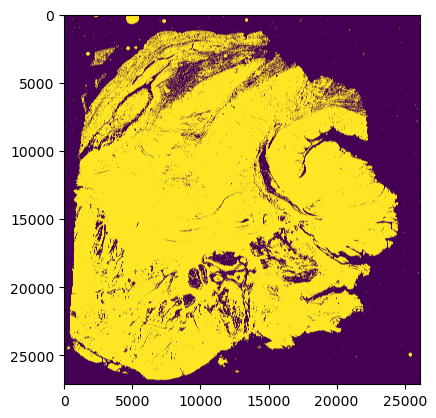


Working on H&E
Pixel size of H&E is 1.0um with an estimated area of 388628561 sq. pixels
Full image dimensions are x=26139, y=27120 pixels


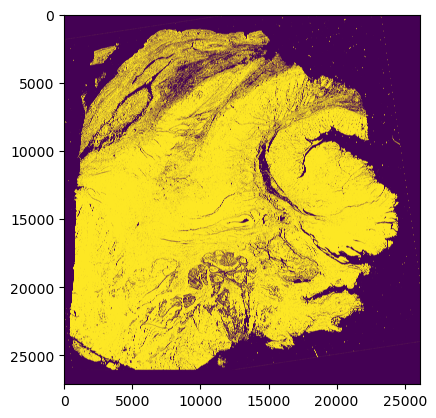


Working on CyCIF-1B
Pixel size of CyCIF-1B is 0.65um with an estimated area of 391643933 sq. pixels
Full image dimensions are x=24897, y=27121 pixels


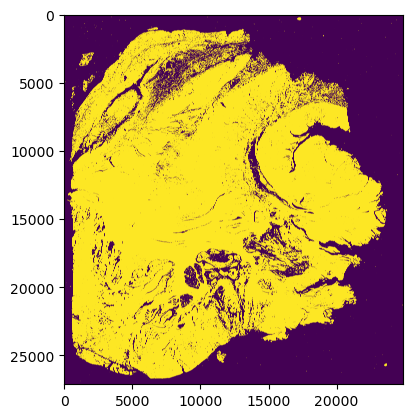


Working on CyCIF-2
Pixel size of CyCIF-2 is 0.65um with an estimated area of 381232014 sq. pixels
Full image dimensions are x=27411, y=22981 pixels


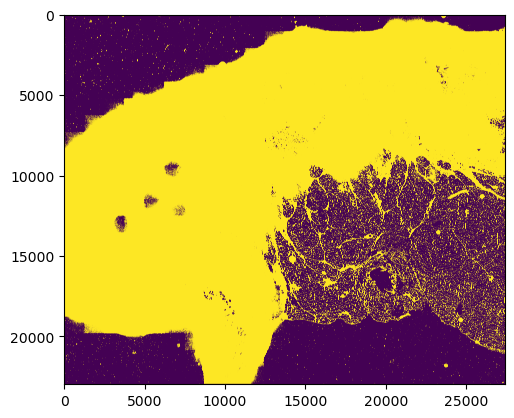

In [3]:
for name, data in paths.items():
    print('Working on', name)
    path = data[0]
    cutoff = data[1]
    
    try:
        ome = from_tiff(path)
        pixel_size = round(ome.images[0].pixels.physical_size_x, 2)
    except:
        print('TIFF metadata unavailable')

    if name == 'H&E':  # this is an 8-bit RGB brightfield image
        # working with first channel only 
        im = imread(path)[..., 0]
        # inverting pixel values so background takes low values
        im = np.invert(im)
        im = np.where(im == 255, 0, im)
    else:
        im = imread(path, key=0)

    binary = (im > cutoff).astype(int)
    count_ones = np.count_nonzero(binary == 1)
    try:
        print(
            f'Pixel size of {name} is {pixel_size}um with an estimated area of {count_ones} sq. pixels'
        )
    except:
        print(
            f'Estimated area of {count_ones} sq. pixels'
        )
        
    print(f'Full image dimensions are x={im.shape[1]}, y={im.shape[0]} pixels')

    plt.imshow(binary)
    plt.savefig(os.path.join(out, f'{name}.png'), dpi=800)
    plt.show()
    print()